In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 100000)
orig_df = pd.read_csv('output.csv')

print(orig_df)

    cache_policy  per_layer_cache  reorder_experts      predict_input_mode  cache_rate  decode_stage_hit_rate  prefill_stage_hit_rate  decode_stage_ready_rate  prefill_stage_ready_rate  legacy_decode_stage_hit_rate  legacy_prefill_stage_hit_rate
0            min             True            False                     NaN    0.015625               0.004563                0.000080                 0.004588                  0.000080                      0.004588                       0.000080
1            lru             True            False                     NaN    0.015625               0.004563                0.000080                 0.004567                  0.000080                      0.004567                       0.000080
2            min            False            False                     NaN    0.015625               0.137230                0.015981                 0.137244                  0.015981                      0.137244                       0.015981
3            lru

In [6]:
# df = orig_df[orig_df['per_layer_cache'] == False]
# print(df['decode_stage_hit_rate'])

0    0.000235
1    0.081121
2    0.128784
3    0.135196
4    0.099159
5    0.092170
6    0.095120
Name: decode_stage_hit_rate, dtype: float64


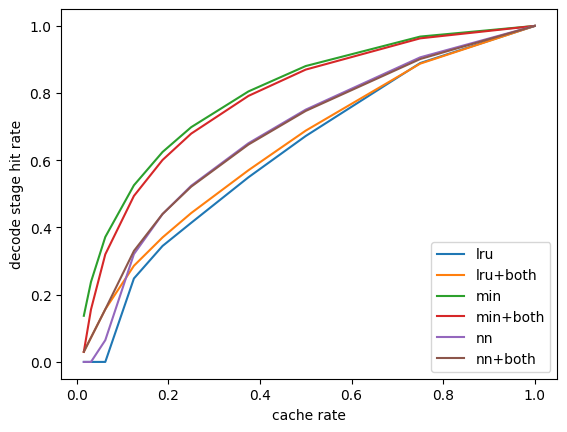

In [2]:
df = orig_df
# df = df[df['per_layer_cache'] == True]
# df = df[df['num_predict_expert_per_layer'] == 0]

x = df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "lru"')['cache_rate']

# print(df.query('per_layer_cache ==  True').query('reorder_experts == False').query('cache_policy == "lru"'))
# print(df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "lru"'))['cache_rate']

plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "lru"')['decode_stage_hit_rate'], label='lru')
# plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts == False').query('cache_policy == "lru"')['decode_stage_hit_rate'], label='lru+per')
# plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts ==  True').query('cache_policy == "lru"')['decode_stage_hit_rate'], label='lru+reorder')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts ==  True').query('cache_policy == "lru"')['decode_stage_hit_rate'], label='lru+both')
plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "min"')['decode_stage_hit_rate'], label='min')
# plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts == False').query('cache_policy == "min"')['decode_stage_hit_rate'], label='min+per')
# plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts ==  True').query('cache_policy == "min"')['decode_stage_hit_rate'], label='min+reorder')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts ==  True').query('cache_policy == "min"')['decode_stage_hit_rate'], label='min+both')

plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts == False').query('predict_input_mode == "weighted_decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn')
# plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts == False').query('predict_input_mode == "weighted_decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn+per')
# plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts ==  True').query('predict_input_mode == "weighted_decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn+reorder')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts ==  True').query('predict_input_mode == "weighted_decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn+both')
# plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts == False').query('predict_input_mode == "decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn')
# # plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts == False').query('predict_input_mode == "decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn+per')
# # plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts ==  True').query('predict_input_mode == "decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn+reorder')
# plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts ==  True').query('predict_input_mode == "decode_cumsum"').query('cache_policy == "nn"')['decode_stage_hit_rate'], label='nn+both')

plt.xlabel('cache rate')
plt.ylabel('decode stage hit rate')
plt.legend()
plt.show()

# plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['decode_stage_forward_time']/1000, label='base')
# plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy ==  "nn"')['decode_stage_forward_time']/1000, label='+nn')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy == "lru"')['decode_stage_forward_time']/1000, label='+prefetch')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy ==  "nn"')['decode_stage_forward_time']/1000, label='+p+n')

# plt.xlabel('cache rate')
# plt.ylabel('decode stage time per token (ms)')
# plt.ylim(bottom=0)
# plt.legend()
# plt.show()

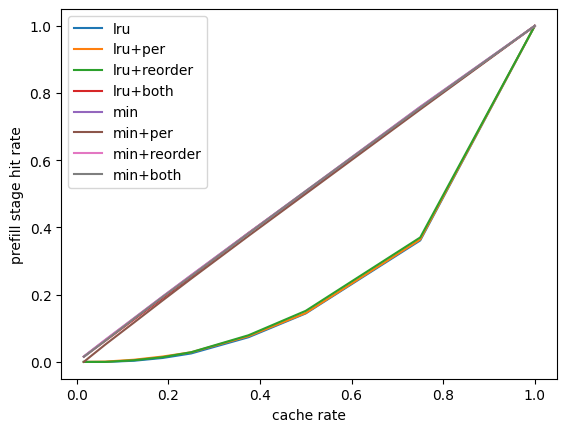

In [3]:
df = orig_df
# df = df[df['per_layer_cache'] == True]
# df = df[df['num_predict_expert_per_layer'] == 0]

x = df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "lru"')['cache_rate']

# print(df.query('per_layer_cache ==  True').query('reorder_experts == False').query('cache_policy == "lru"'))
# print(df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "lru"'))['cache_rate']

plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "lru"')['prefill_stage_hit_rate'], label='lru')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts == False').query('cache_policy == "lru"')['prefill_stage_hit_rate'], label='lru+per')
plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts ==  True').query('cache_policy == "lru"')['prefill_stage_hit_rate'], label='lru+reorder')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts ==  True').query('cache_policy == "lru"')['prefill_stage_hit_rate'], label='lru+both')
plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts == False').query('cache_policy == "min"')['prefill_stage_hit_rate'], label='min')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts == False').query('cache_policy == "min"')['prefill_stage_hit_rate'], label='min+per')
plt.plot(x, df.query('per_layer_cache == False').query('reorder_experts ==  True').query('cache_policy == "min"')['prefill_stage_hit_rate'], label='min+reorder')
plt.plot(x, df.query('per_layer_cache ==  True').query('reorder_experts ==  True').query('cache_policy == "min"')['prefill_stage_hit_rate'], label='min+both')
plt.xlabel('cache rate')
plt.ylabel('prefill stage hit rate')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


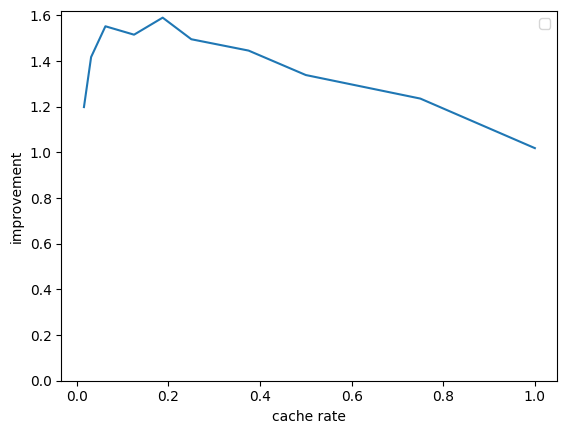

In [4]:
import numpy as np
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['cache_rate']

subset = df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')
y1 = np.asarray(subset['decode_stage_forward_time']/1000)
subset = df.query('num_predict_expert_per_layer == 6').query('reorder_experts == True').query('early_preempt == True')
y2 = np.asarray(subset['decode_stage_forward_time']/1000)

plt.plot(subset['cache_rate'], y1/y2)
# plt.plot(subset['cache_rate'], y2)


plt.xlabel('cache rate')
plt.ylabel('improvement')
plt.ylim(bottom=0)
plt.legend()
plt.show()